In [19]:
import urllib.request

url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
file_name = "shape_predictor_68_face_landmarks.dat.bz2"

if not os.path.exists("shape_predictor_68_face_landmarks.dat"):
    print("Downloading landmark model...")

    urllib.request.urlretrieve(url, file_name)

    import bz2

    with bz2.BZ2File(file_name) as fr, open("shape_predictor_68_face_landmarks.dat", "wb") as fw:
        fw.write(fr.read())

    print("Model downloaded and extracted.")

Dataset Path: repo/facial_recognition-main/processed_data
Processing dataset...


100%|██████████| 54/54 [00:03<00:00, 16.18it/s]


Saved: face_embeddings.npz

FAILED IMAGES: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Samples:


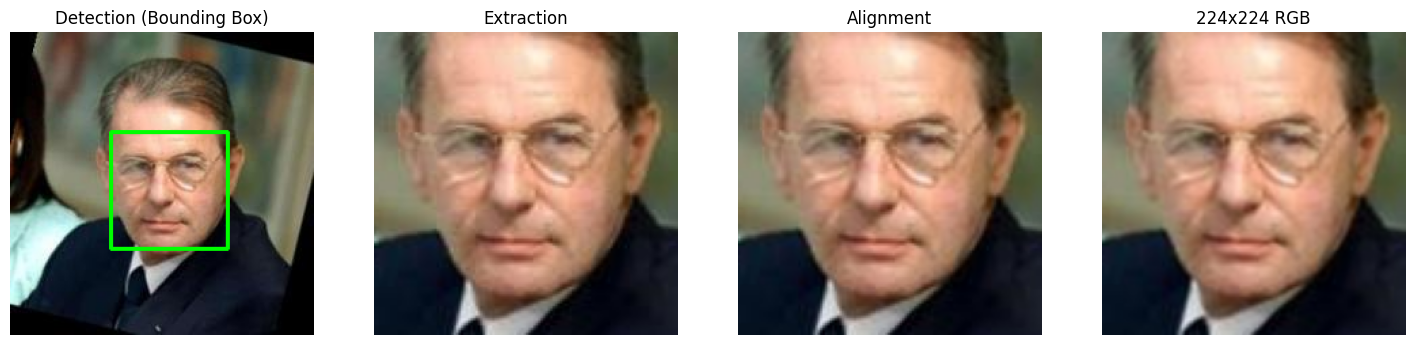

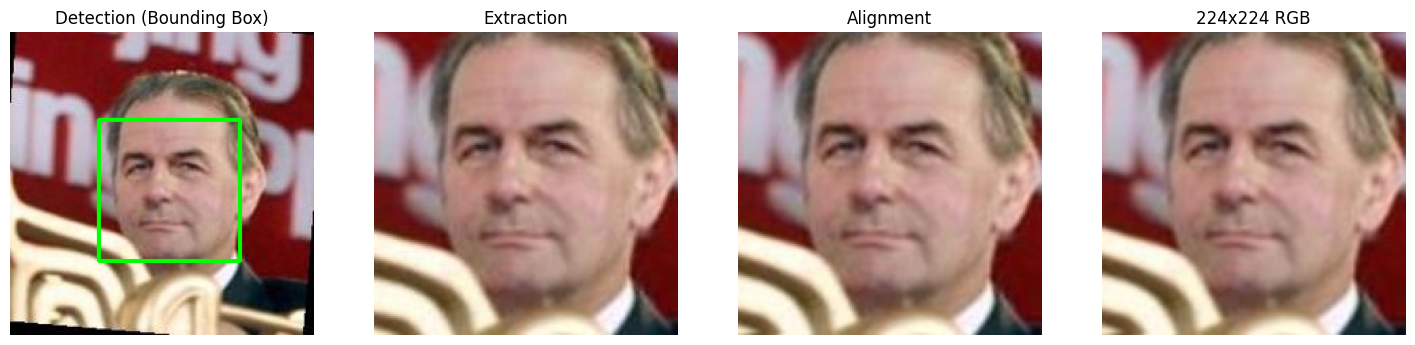

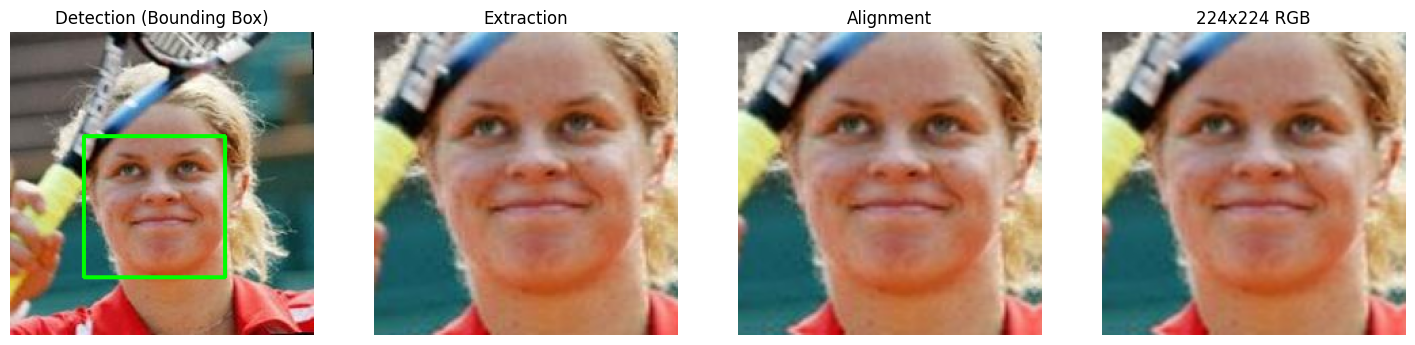

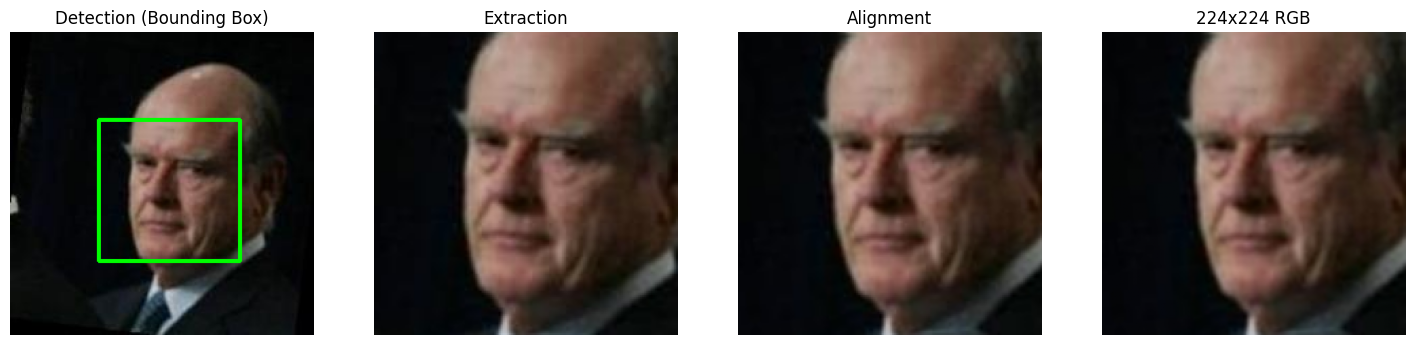

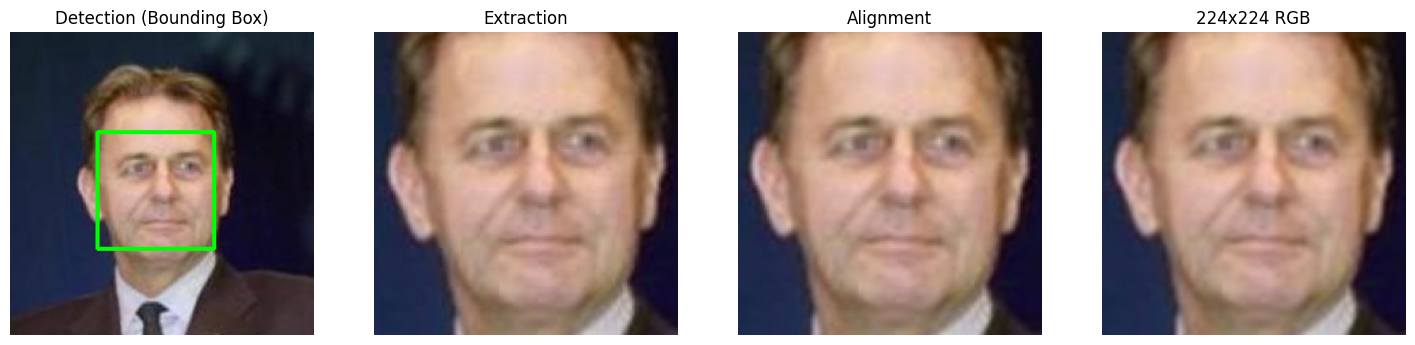

In [21]:
# ==========================================================
# DELIVERABLE 2 - FACE PIPELINE
# Detection → Extraction → Alignment → Preprocessing → Embeddings
# ==========================================================

# -------------------------------
# INSTALL DEPENDENCIES
# -------------------------------
!pip install opencv-python dlib matplotlib tqdm face_recognition requests

# -------------------------------
# IMPORT LIBRARIES
# -------------------------------
import os
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import face_recognition
import shutil
import random
import requests
from zipfile import ZipFile

# -------------------------------
# REPRODUCIBILITY
# -------------------------------
random.seed(42)
np.random.seed(42)

# ==========================================================
# SETTINGS
# ==========================================================
github_repo_zip_url = "https://github.com/Nayanapmku/facial_recognition/archive/refs/heads/main.zip"

input_root = "processed_data"
output_dir = "preprocess_aligned"
embedding_file = "face_embeddings.npz"

desired_size = 224
num_samples = 5

# ==========================================================
# DOWNLOAD DATASET
# ==========================================================
if not os.path.exists(input_root):

    print("Downloading dataset...")

    r = requests.get(github_repo_zip_url, stream=True)
    with open("repo.zip", "wb") as f:
        for chunk in r.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)

    with ZipFile("repo.zip", "r") as zip_ref:
        zip_ref.extractall("repo")

    for root, dirs, files in os.walk("repo"):
        if input_root in dirs:
            input_root = os.path.join(root, input_root)
            break

print("Dataset Path:", input_root)

# ==========================================================
# MODELS
# ==========================================================
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# ==========================================================
# FACE DETECTION
# ==========================================================
def detect_faces(img):
    return detector(img)

# ==========================================================
# SAFE FACE EXTRACTION (IN-MEMORY)
# ==========================================================
def extract_face(img, rect, pad=20):
    x1 = max(rect.left() - pad, 0)
    y1 = max(rect.top() - pad, 0)
    x2 = min(rect.right() + pad, img.shape[1])
    y2 = min(rect.bottom() + pad, img.shape[0])

    face = img[y1:y2, x1:x2]

    return face if face.size != 0 else None

# ==========================================================
# FACE ALIGNMENT
# ==========================================================
def align_face(face_img):
    try:
        gray = cv2.cvtColor(face_img, cv2.COLOR_RGB2GRAY)
        rect = dlib.rectangle(0, 0, face_img.shape[1], face_img.shape[0])
        landmarks = predictor(gray, rect)

        left_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(36,42)], axis=0)
        right_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(42,48)], axis=0)

        dx = right_eye[0] - left_eye[0]
        dy = right_eye[1] - left_eye[1]
        angle = np.degrees(np.arctan2(dy, dx))

        eyes_center = ((left_eye[0] + right_eye[0]) / 2,
                       (left_eye[1] + right_eye[1]) / 2)

        M = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)

        aligned = cv2.warpAffine(
            face_img,
            M,
            (face_img.shape[1], face_img.shape[0]),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REFLECT
        )

        return aligned

    except:
        return None

# ==========================================================
# PREPROCESSING (FORCED RGB + NORMALIZATION + SIZE)
# ==========================================================
def preprocess(img):
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (desired_size, desired_size))
    img = img / 255.0

    return img

# ==========================================================
# SAVE IMAGE
# ==========================================================
def save_image(img, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.imsave(path, (img * 255).astype(np.uint8))

# ==========================================================
# EMBEDDINGS
# ==========================================================
def get_embedding(img):
    img_uint8 = (img * 255).astype(np.uint8)
    enc = face_recognition.face_encodings(img_uint8)
    return enc[0] if len(enc) > 0 else None

# ==========================================================
# PROCESS DATASET
# ==========================================================
print("Processing dataset...")

embeddings = {
    "train_embeddings": [], "train_labels": [],
    "val_embeddings": [], "val_labels": [],
    "test_embeddings": [], "test_labels": []
}

image_paths = []
for root, dirs, files in os.walk(input_root):
    for f in files:
        if f.lower().endswith((".jpg",".jpeg",".png")):
            image_paths.append(os.path.join(root,f))

sample_images = random.sample(image_paths, min(num_samples, len(image_paths)))

failed = []

for img_path in tqdm(image_paths):

    img = cv2.imread(img_path)
    if img is None:
        failed.append((img_path, "read failed"))
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = detect_faces(img_rgb)
    if len(faces) == 0:
        failed.append((img_path, "no face"))
        continue

    face = extract_face(img_rgb, faces[0])
    if face is None:
        failed.append((img_path, "crop failed"))
        continue

    aligned = align_face(face)
    if aligned is None:
        failed.append((img_path, "alignment failed"))
        continue

    processed = preprocess(aligned)
    if processed is None:
        failed.append((img_path, "preprocess failed"))
        continue

    # save aligned dataset
    rel_path = img_path.replace(input_root, "").lstrip("/")
    save_image(processed, os.path.join(output_dir, rel_path))

    emb = get_embedding(processed)
    if emb is None:
        failed.append((img_path, "embedding failed"))
        continue

    path_lower = img_path.lower()

    if "train" in path_lower:
        embeddings["train_embeddings"].append(emb)
        embeddings["train_labels"].append(os.path.basename(os.path.dirname(img_path)))

    elif "val" in path_lower:
        embeddings["val_embeddings"].append(emb)
        embeddings["val_labels"].append(os.path.basename(os.path.dirname(img_path)))

    elif "test" in path_lower:
        embeddings["test_embeddings"].append(emb)
        embeddings["test_labels"].append(os.path.basename(os.path.dirname(img_path)))

# ==========================================================
# SAVE EMBEDDINGS
# ==========================================================
np.savez(
    embedding_file,
    train_embeddings=np.array(embeddings["train_embeddings"]),
    train_labels=np.array(embeddings["train_labels"]),
    val_embeddings=np.array(embeddings["val_embeddings"]),
    val_labels=np.array(embeddings["val_labels"]),
    test_embeddings=np.array(embeddings["test_embeddings"]),
    test_labels=np.array(embeddings["test_labels"])
)

print("\nSaved:", embedding_file)

# ==========================================================
# FAILURE REPORT
# ==========================================================
print("\nFAILED IMAGES:", len(failed))
for f in failed[:10]:
    print(f)

# ==========================================================
# DOWNLOAD OUTPUTS
# ==========================================================
shutil.make_archive(output_dir, "zip", output_dir)

from google.colab import files
files.download(output_dir + ".zip")
files.download(embedding_file)

# ==========================================================
# VISUALIZATION (FIXED - WITH BOUNDING BOX)
# ==========================================================
def visualize(img_path):

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = detect_faces(img_rgb)
    if len(faces) == 0:
        return

    face_rect = faces[0]

    # BOUNDING BOX
    img_box = img_rgb.copy()
    cv2.rectangle(
        img_box,
        (face_rect.left(), face_rect.top()),
        (face_rect.right(), face_rect.bottom()),
        (0,255,0),
        2
    )

    face = extract_face(img_rgb, face_rect)
    aligned = align_face(face)
    processed = preprocess(aligned)

    fig, ax = plt.subplots(1,4, figsize=(18,5))

    ax[0].imshow(img_box)
    ax[0].set_title("Detection (Bounding Box)")
    ax[0].axis("off")

    ax[1].imshow(face)
    ax[1].set_title("Extraction")
    ax[1].axis("off")

    ax[2].imshow(aligned)
    ax[2].set_title("Alignment")
    ax[2].axis("off")

    ax[3].imshow(processed)
    ax[3].set_title("224x224 RGB")
    ax[3].axis("off")

    plt.show()

print("\nSamples:")
for i in sample_images:
    visualize(i)